# SMIC Spatio-Temporal Dataset & DataLoader (3D)

## Peta proyek (baca dulu sebelum sidang)

Workspace aktif ada di `python test/`. Setiap arsitektur **diisolasi** di foldernya sendiri agar checkpoint `.pth` dan notebook tidak tercampur.

```text
python test/
├── discovery/          # EDA saja — tidak ada training
│   ├── smic_data_discovery.ipynb
│   └── mmew_data_discovery.ipynb
├── stgcn/              # model graf Face Mesh (468 node)
│   ├── stgcn_mmew_extraction.ipynb
│   ├── stgcn_mmew_pretraining.ipynb
│   ├── stgcn_smic_extraction.ipynb
│   ├── stgcn_smic_training.ipynb   # LOSO + transfer MMEW
│   ├── stgcn_mmew_pretrained.pth
│   ├── stgcn_best_model.pth
│   └── stgcn_mmew_landmarks/       # 300 file .npy MMEW
├── r3d18/              # 3D-CNN R3D-18 pada klip video
│   ├── r3d18_smic_pipeline.ipynb
│   └── r3d18_best_model.pth
├── vit/                # ViT pada gambar Optical Flow
│   ├── vit_optical_flow_pipeline.ipynb
│   └── vit_best_model.pth
├── dataset/            # data mentah + hasil ekstraksi bersama
│   ├── SMIC_all_cropped/           # frame BMP ter-crop & registrasi
│   ├── MMEW/                       # JPG mikro (sekuens) + makro (still)
│   ├── stgcn_smic_landmarks/       # .npy graf SMIC
│   └── vit_optical_flow_frames/    # JPG flow untuk ImageFolder
└── requirements.txt
```

**Alur skripsi yang benar:** discovery → ekstraksi fitur → (opsional pre-train) → LOSO SMIC. Ketiga model dievaluasi dengan protokol **LOSO** yang sama agar perbandingan adil (tanpa Subject Leakage dari split 80/20).

**Letak di peta:** `r3d18/` membaca frame mentah `../dataset/SMIC_all_cropped/` (bukan landmark). Tensor model: **`(N, C, T, H, W)`** — batch × RGB × waktu × tinggi × lebar.

Catatan: komentar lama menyebut 224×224, tetapi `IMG_SIZE = 112` agar R3D-18 muat di memori Apple Silicon. Bobot Kinetics tetap bisa fine-tune pada 112.

Notebook ini membangun **Custom Dataset PyTorch** untuk klip mikro-ekspresi SMIC modalitas **HS**. Setiap sampel adalah satu folder sequence berisi frame `.bmp`, bukan satu gambar mandiri.

Pipeline:

1. Filter indeks hanya pada `SMIC_all_cropped/HS/{subjek}/micro/{emosi}/{klip}`
2. Mapping label emosi ke integer
3. Uniform sampling menjadi tepat **16 frame**
4. Resize spasial **224×224** + normalisasi ImageNet
5. Tensor keluaran `(C, T, H, W)` = `(3, 16, 224, 224)`
6. Evaluasi **Leave-One-Subject-Out (LOSO)** untuk mencegah Subject Leakage
7. Sanity check dimensi batch dan visualisasi 16 frame

> Jika notebook `smic_data_discovery.ipynb` sudah dijalankan pada kernel yang sama, DataFrame `micro_df` dipakai ulang. Jika belum, indeks klip dibangun otomatis dari struktur folder.


In [1]:
# =============================================================================
# 1. IMPORT, KONFIGURASI, DAN MAPPING LABEL
# =============================================================================
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from sklearn.model_selection import LeaveOneGroupOut

# ==========================================
# KONFIGURASI EKSEKUSI (Lokal vs Server)
# ==========================================
RUN_ON_SERVER = False  # Ubah ke True jika dijalankan di server GPU berkapasitas tinggi

if RUN_ON_SERVER:
    CFG = {
        "epochs": 150,
        "batch_size": 32,
        "use_augmentation": True,
        "patience": 20,
        "num_workers": 4
    }
else:
    CFG = {
        "epochs": 2,
        "batch_size": 4,
        "use_augmentation": False,
        "patience": 2,
        "num_workers": 0
    }

print(f"Mode eksekusi : {'SERVER' if RUN_ON_SERVER else 'LOKAL'}")
print(f"CFG           : {CFG}")

# Root dataset: satu tingkat di atas folder r3d18/ (python test/)
DATASET_ROOT = Path('../dataset/SMIC_all_cropped').resolve()

# Konfigurasi temporal dan spasial
# T=16 sama dengan ST-GCN/ViT sampling agar perbandingan protokol temporal sejajar.
NUM_FRAMES = 16          # setiap klip dipaksa memiliki tepat 16 frame
# 112 bukan 224: volume 3D = C×T×H×W. 224³ memori meledak; 112 adalah kompromi akurasi vs OOM.
IMG_SIZE = 112           # resolusi spasial input 3D-CNN / backbone (diperkecil untuk hemat memori)
BATCH_SIZE = CFG["batch_size"]
RANDOM_SEED = 42         # seed split train/val agar reprodusibel
NUM_WORKERS = CFG["num_workers"]
USE_AUGMENTATION = CFG["use_augmentation"]

# Mapping label string -> integer (urut tetap, jangan diubah setelah training)
LABEL_TO_INDEX = {
    'Negative': 0,
    'Positive': 1,
    'Surprise': 2,
}
INDEX_TO_LABEL = {idx: name for name, idx in LABEL_TO_INDEX.items()}

# Statistik ImageNet — wajib untuk transfer learning dari backbone RGB
# Statistik ImageNet: R3D Kinetics dilatih pada RGB ternormalisasi. Tanpa ini, distribusi input bergeser
# dan fitur pre-trained tidak nyala (covariate shift).
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        f'Folder dataset tidak ditemukan: {DATASET_ROOT}\n'
        'Sesuaikan DATASET_ROOT dengan lokasi SMIC_all_cropped.'
    )

print(f'Dataset root : {DATASET_ROOT}')
print(f'NUM_FRAMES   : {NUM_FRAMES}')
print(f'IMG_SIZE     : {IMG_SIZE}')
print(f'Label mapping: {LABEL_TO_INDEX}')
print(f'Augmentasi train : {"AKTIF" if USE_AUGMENTATION else "NONAKTIF"} (hanya fold train, bukan val)')


Dataset root : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/SMIC_all_cropped
NUM_FRAMES   : 16
IMG_SIZE     : 112
Label mapping: {'Negative': 0, 'Positive': 1, 'Surprise': 2}


## 2. Persiapan Data (Filtering)

Hanya klip **HS + micro** yang dipakai. Folder `non_micro`, serta modalitas NIR/VIS, tidak dimasukkan ke Dataset 3D pada tahap ini.
**Hanya HS/micro.** NIR dan VIS bisa merekam kejadian yang sama (pasangan kamera). Mencampur modalitas tanpa grouping event = duplikasi sampel dan kebocoran evaluasi.


In [2]:
# =============================================================================
# 2. BANGUN INDEKS KLIP HS / MICRO
# =============================================================================
def frame_sort_key(frame_path: Path):
    """Urutkan nama file berdasarkan angka terakhir, bukan alfabet murni.

    Contoh: reg_image9.bmp harus muncul sebelum reg_image10.bmp.
    """
    # Urut numerik: tanpa ini reg_10.bmp muncul sebelum reg_2.bmp dan gerak 3D-CNN menjadi kacau.
    numbers = re.findall(r'\d+', frame_path.stem)
    return (0, int(numbers[-1])) if numbers else (1, frame_path.name)


def list_clip_frames(clip_dir: str | Path) -> list[Path]:
    """Ambil seluruh frame .bmp di dalam satu folder klip, tersortir numerik."""
    clip_dir = Path(clip_dir)
    frames = [
        path for path in clip_dir.iterdir()
        if path.is_file() and path.suffix.lower() == '.bmp'
    ]
    return sorted(frames, key=frame_sort_key)


def build_hs_micro_index(dataset_root: Path) -> pd.DataFrame:
    """Cari folder klip pada pola */HS/{subjek}/micro/{emosi}/{nama_klip}."""
    records = []
    hs_root = dataset_root / 'HS'
    if not hs_root.is_dir():
        raise FileNotFoundError(f'Folder HS tidak ditemukan: {hs_root}')

    # glob: HS / subjek / micro / emosi / klip
    for clip_dir in sorted(hs_root.glob('*/micro/*/*')):
        if not clip_dir.is_dir():
            continue

        frames = list_clip_frames(clip_dir)
        if not frames:
            continue

        emotion_folder = clip_dir.parent.name  # negative / positive / surprise
        emotion_label = emotion_folder.capitalize()
        if emotion_label not in LABEL_TO_INDEX:
            continue

        records.append({
            'sequence_path': str(clip_dir.resolve()),
            'subject_id': clip_dir.parts[-4],
            'emotion_label': emotion_label,
            'sequence_id': clip_dir.name,
            'num_frames': len(frames),
            'modality': 'HS',
            'sample_type': 'Micro',
        })

    return pd.DataFrame(records)


# Pakai micro_df dari notebook discovery jika tersedia; jika tidak, bangun ulang.
if 'micro_df' in globals() and isinstance(micro_df, pd.DataFrame) and not micro_df.empty:
    clip_df = micro_df.copy()
    print('Menggunakan micro_df dari tahap eksplorasi sebelumnya.')
else:
    clip_df = build_hs_micro_index(DATASET_ROOT)
    print('micro_df tidak tersedia di kernel. Indeks klip dibangun dari folder HS/micro.')

# Filter ketat: hanya HS + tiga kelas mikro-ekspresi
clip_df = clip_df[
    (clip_df['modality'] == 'HS')
    & (clip_df['sample_type'] == 'Micro')
    & (clip_df['emotion_label'].isin(LABEL_TO_INDEX.keys()))
].copy()

# Pastikan kolom path sequence ada (nama kolom di discovery: sequence_path)
if 'sequence_path' not in clip_df.columns:
    raise KeyError('Kolom sequence_path tidak ditemukan pada DataFrame indeks.')

# Mapping label integer
clip_df['label'] = clip_df['emotion_label'].map(LABEL_TO_INDEX)
clip_df = clip_df.reset_index(drop=True)

print(f'\nTotal klip HS/micro: {len(clip_df)}')
print('Distribusi kelas:')
print(clip_df['emotion_label'].value_counts().reindex(['Negative', 'Positive', 'Surprise']))
print('\nLima baris pertama:')
clip_df.head()


micro_df tidak tersedia di kernel. Indeks klip dibangun dari folder HS/micro.

Total klip HS/micro: 164
Distribusi kelas:
emotion_label
Negative    70
Positive    51
Surprise    43
Name: count, dtype: int64

Lima baris pertama:


,sequence_path,subject_id,emotion_label,sequence_id,num_frames,modality,sample_type,label
0,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_01,36,HS,Micro,0
1,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_02,32,HS,Micro,0
2,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_03,27,HS,Micro,0
3,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Positive,s1_po_01,23,HS,Micro,1
4,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Positive,s1_po_02,30,HS,Micro,1


## 3. Custom Dataset 3D — `SMICVideoDataset`

Setiap `__getitem__` melakukan:

1. Membaca daftar frame `.bmp` yang sudah diurutkan numerik
2. **Uniform sampling** dengan `np.linspace` agar panjang temporal selalu `NUM_FRAMES`
3. Memuat tiap frame, mengubah BGR→RGB, lalu menerapkan transforms spasial
4. Menyusun tensor `(C, T, H, W)`

Jika klip asli lebih pendek dari 16 frame, indeks sampling akan berulang sehingga panjang tetap 16.
**`(C, T, H, W)` vs ST-GCN `(C, T, V)`:** 3D-CNN menggulung **piksel** sepanjang ruang dan waktu. ST-GCN menggulung **node graf**. Keduanya butuh `T` konstan, itulah fungsi `np.linspace`.


In [3]:
# =============================================================================
# 3. CUSTOM DATASET: MEMBACA SEQUENCE BMP SEBAGAI VIDEO 3D
# =============================================================================
def uniform_sample_indices(num_available: int, num_target: int) -> np.ndarray:
    """Ambil num_target indeks secara merata sepanjang sequence.

    np.linspace menjamin ujung awal dan akhir sequence ikut terwakili.
    Jika num_available < num_target, beberapa frame akan terulang.
    """
    if num_available <= 0:
        raise ValueError('Sequence tidak memiliki frame.')
    if num_available == 1:
        return np.zeros(num_target, dtype=int)

    indices = np.linspace(0, num_available - 1, num=num_target)
    indices = np.round(indices).astype(int)
    return np.clip(indices, 0, num_available - 1)


# Eval/val: tanpa augmentasi. Flip/jitter pada val akan merusak protokol LOSO.
eval_frame_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # [0, 1], shape (C, H, W)
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Train: flip/rotasi/jitter ringan hanya jika CFG['use_augmentation'] True (mode server).
# Diterapkan per-frame dengan seed yang sama agar 16 frame satu klip tidak ter-flip acak berbeda.
train_frame_transforms = eval_frame_transforms
if USE_AUGMENTATION:
    train_frame_transforms = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
frame_transforms = eval_frame_transforms  # default dataset (sanity check = eval)


class SMICVideoDataset(Dataset):
    """Dataset spatio-temporal SMIC: satu folder klip = satu sampel video."""

    def __init__(
        self,
        clip_table: pd.DataFrame,
        num_frames: int = NUM_FRAMES,
        transform=eval_frame_transforms,
        augment: bool = False,
    ):
        # Salinan agar pemanggilan berulang tidak mengubah DataFrame asli
        self.clip_table = clip_table.reset_index(drop=True)
        self.num_frames = num_frames
        self.transform = transform
        self.augment = augment

    def __len__(self) -> int:
        return len(self.clip_table)

    def __getitem__(self, index: int):
        row = self.clip_table.iloc[index]
        clip_dir = Path(row['sequence_path'])
        label = int(row['label'])

        # Urutan temporal harus numerik, bukan sorted() alfabetik murni
        frame_paths = list_clip_frames(clip_dir)
        if not frame_paths:
            raise FileNotFoundError(f'Tidak ada frame .bmp di {clip_dir}')

        # Uniform sampling: pilih tepat NUM_FRAMES indeks merata
        sampled_idx = uniform_sample_indices(len(frame_paths), self.num_frames)
        sampled_paths = [frame_paths[i] for i in sampled_idx]

        tensors = []
        for frame_path in sampled_paths:
            # OpenCV membaca BGR; konversi ke RGB agar sesuai ImageNet
            image_bgr = cv2.imread(str(frame_path), cv2.IMREAD_COLOR)
            if image_bgr is None:
                raise IOError(f'Gagal membaca frame: {frame_path}')
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

            # transform menghasilkan (C, H, W)
            # Satu seed per klip: flip/rotasi sama di 16 frame (gerak temporal tetap koheren).
            if self.augment:
                torch.manual_seed(index)
            tensors.append(self.transform(image_rgb))

        # stack pada dim=0 -> (T, C, H, W), lalu permute ke (C, T, H, W)
        # stack → (T,C,H,W); permute(1,0,2,3) → (C,T,H,W) sesuai r3d_18 (channel dulu, waktu kedua).
        video_tensor = torch.stack(tensors, dim=0).permute(1, 0, 2, 3)
        return video_tensor, label


eval_dataset = SMICVideoDataset(
    clip_df, num_frames=NUM_FRAMES, transform=eval_frame_transforms, augment=False,
)
train_dataset_aug = SMICVideoDataset(
    clip_df, num_frames=NUM_FRAMES, transform=train_frame_transforms, augment=USE_AUGMENTATION,
)
dataset = eval_dataset  # dipakai sanity-check dan val LOSO

sample_video, sample_label = dataset[0]
print(f'Contoh sampel ke-0:')
print(f'  sequence_id : {clip_df.iloc[0]["sequence_id"]}')
print(f'  label       : {sample_label} ({INDEX_TO_LABEL[sample_label]})')
print(f'  tensor shape: {tuple(sample_video.shape)}  (C, T, H, W)')


Contoh sampel ke-0:
  sequence_id : s1_ne_01
  label       : 0 (Negative)
  tensor shape: (3, 16, 112, 112)  (C, T, H, W)


## 4. Persiapan LOSO (Leave-One-Subject-Out)

Split acak 80/20 **tidak dipakai** karena dapat menyebabkan **Subject Leakage**: klip subjek yang sama (misalnya `s3` dengan 39 klip) bisa terbagi ke train dan val sekaligus sehingga model belajar mengenali identitas subjek, bukan ekspresi.

Protokol **LOSO** menahan seluruh klip satu subjek sebagai validasi, sementara subjek lain dipakai untuk training. Setiap fold menghasilkan prediksi yang kemudian diakumulasi untuk metrik global.
**LeaveOneGroupOut:** `groups[i]` = `s1`, `s2`, … sklearn menjamin tidak ada indeks subjek val yang muncul di train. Inilah definisi operasional anti-Subject-Leakage.


In [4]:
# =============================================================================
# 4. EKSTRAKSI SUBJECT ID & PEMBAGIAN LOSO
# =============================================================================
def parse_subject_id(sequence_id: str) -> str:
    """Ambil ID subjek dari nama klip, misalnya 's1_ne_01' -> 's1'."""
    match = re.match(r'(s\d+)', str(sequence_id), flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f'ID subjek tidak dapat diekstrak dari: {sequence_id}')
    return match.group(1).lower()


# groups[i] = ID subjek pemilik klip ke-i, dipakai LeaveOneGroupOut
groups = clip_df['sequence_id'].map(parse_subject_id).tolist()
labels_all = clip_df['label'].tolist()

# LOSO mencegah Subject Leakage: satu subjek penuh jadi validasi per fold
# groups[i] = 's1'..'s16'. sklearn menjamin subjek val tidak muncul di train — definisi LOSO.
logo = LeaveOneGroupOut()
fold_splits = list(
    logo.split(X=np.arange(len(eval_dataset)), y=labels_all, groups=groups)
)
n_folds = len(fold_splits)

unique_subjects = sorted(set(groups), key=lambda s: int(s[1:]))
print(f'Total klip     : {len(eval_dataset)}')
print(f'Jumlah subjek  : {len(unique_subjects)} -> {n_folds} fold LOSO')
print(f'Batch size     : {BATCH_SIZE}')
print('Jumlah klip per subjek:')
print(clip_df.assign(subject_id=groups)['subject_id'].value_counts().reindex(unique_subjects).to_string())

# --- Sanity check dimensi 1 batch dari fold pertama (data train) ---
check_train_idx, _ = fold_splits[0]
check_loader = DataLoader(
    Subset(train_dataset_aug, check_train_idx.tolist()),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
inputs, labels = next(iter(check_loader))
print('\nSanity check 1 batch (fold 1, data train):')
print(f'  inputs shape : {tuple(inputs.shape)}  (N, C, T, H, W)')
print(f'  labels shape : {tuple(labels.shape)}')
print(f'  labels       : {labels.tolist()}')
print(f'  label names  : {[INDEX_TO_LABEL[int(x)] for x in labels]}')


Total klip     : 164
Jumlah subjek  : 16 -> 16 fold LOSO
Batch size     : 4
Jumlah klip per subjek:
subject_id
s1      6
s2      6
s3     39
s4     19
s5      2
s6      4
s8     13
s9      4
s11     7
s12     9
s13    10
s14    10
s15     4
s18     7
s19     2
s20    22

Sanity check 1 batch (fold 1, data train):
  inputs shape : (4, 3, 16, 112, 112)  (N, C, T, H, W)
  labels shape : (4,)
  labels       : [0, 1, 0, 0]
  label names  : ['Negative', 'Positive', 'Negative', 'Negative']


## 5. Visualisasi 16 Frame (Grid 4×4)

Tensor masih dalam skala normalisasi ImageNet, sehingga harus di-un-normalize (`img * std + mean`) sebelum ditampilkan. Grid membaca 16 frame dari **satu sampel** dalam batch.

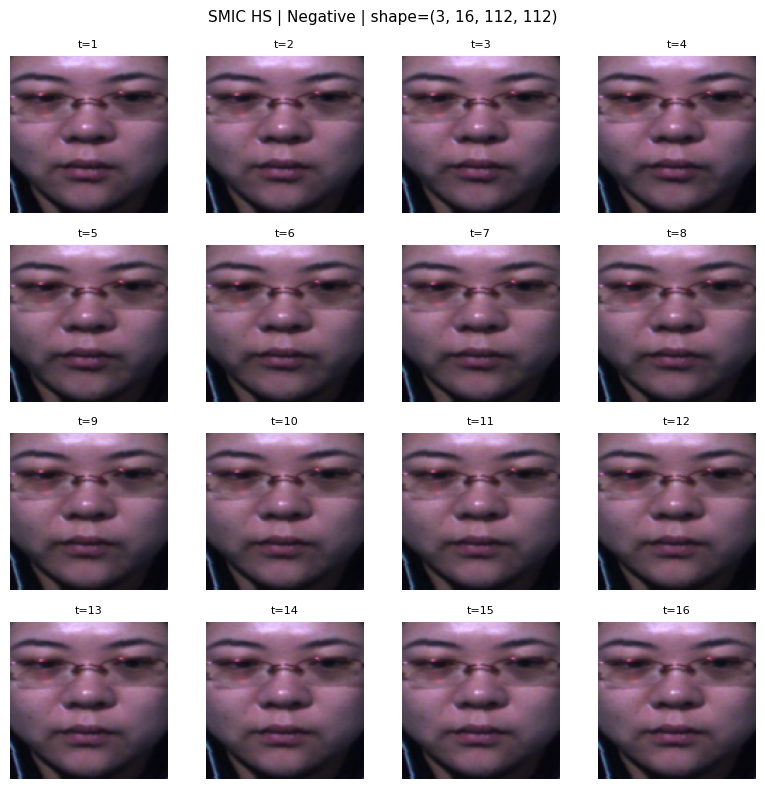

In [5]:
# =============================================================================
# 5. PLOT 16 FRAME SATU SAMPEL — GRID 4x4
# =============================================================================
def unnormalize_video(video_cthw: torch.Tensor) -> torch.Tensor:
    """Kembalikan tensor (C, T, H, W) dari skala ImageNet ke rentang [0, 1]."""
    mean = torch.tensor(IMAGENET_MEAN, dtype=video_cthw.dtype).view(3, 1, 1, 1)
    std = torch.tensor(IMAGENET_STD, dtype=video_cthw.dtype).view(3, 1, 1, 1)
    video = video_cthw * std + mean
    return torch.clamp(video, 0.0, 1.0)


def show_clip_frames(video_cthw: torch.Tensor, title: str, nrow: int = 4):
    """Tampilkan T frame dalam grid nrow x nrow (default 4x4 untuk 16 frame)."""
    video = unnormalize_video(video_cthw.detach().cpu())
    _, num_time, _, _ = video.shape

    fig, axes = plt.subplots(nrow, nrow, figsize=(8, 8))
    axes = np.array(axes).reshape(-1)

    for t in range(nrow * nrow):
        ax = axes[t]
        ax.axis('off')
        if t >= num_time:
            continue
        # (C, H, W) -> (H, W, C) untuk matplotlib
        frame = video[:, t].permute(1, 2, 0).numpy()
        ax.imshow(frame)
        ax.set_title(f't={t + 1}', fontsize=8)

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# Ambil sampel pertama pada batch yang sudah diambil
sample_index = 0
sample_input = inputs[sample_index]          # (C, T, H, W)
sample_class = INDEX_TO_LABEL[int(labels[sample_index])]

show_clip_frames(
    sample_input,
    title=f'SMIC HS | {sample_class} | shape={tuple(sample_input.shape)}',
    nrow=4,
)

# 6. Baseline 3D-CNN — ResNet-18 Video (`r3d_18`) + Evaluasi LOSO

Bagian ini fine-tune **R3D-18 pre-trained Kinetics-400** dengan protokol **Leave-One-Subject-Out (LOSO)**.

Alasan arsitektur ini:

- Input native-nya adalah tensor **5D** `(B, C, T, H, W)`, sama dengan keluaran `dataset`.
- Bobot Kinetics-400 sudah mempelajari pola gerak spatio-temporal, sehingga learning rate dibuat kecil (`1e-4`) untuk fine-tuning.
- Karena kelas SMIC tidak seimbang, evaluasi memakai **Accuracy**, **Macro F1**, dan **UAR** secara global.

> **LOSO mencegah Subject Leakage.** Model, optimizer, dan scheduler di-reset total pada setiap fold agar tidak ada weight leakage antar subjek.
**Kinetics-400:** pre-training aksi manusia (bukan mikro-ekspresi). Tetap berguna karena filter 3D sudah peka gerak. Karena itu LR fine-tune **1e-4**, bukan 1e-3.

**Ganti `model.fc`:** Kinetics punya 400 kelas. SMIC 3 kelas. Kepala klasifikasi diinisialisasi ulang; backbone 3D dipertahankan.


In [6]:
# =============================================================================
# 6. DEVICE, FACTORY MODEL R3D-18, LOSS, OPTIMIZER, DAN SCHEDULER
# =============================================================================
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, recall_score
from torchvision.models.video import R3D_18_Weights, r3d_18
from tqdm.auto import tqdm

# --- Pastikan dataset dan fold LOSO dari cell sebelumnya sudah ada ---
required_vars = ['eval_dataset', 'train_dataset_aug', 'fold_splits', 'groups', 'LABEL_TO_INDEX']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise NameError(
        'Variabel belum tersedia: ' + ', '.join(missing) + '. '
        'Jalankan cell Dataset dan LOSO terlebih dahulu.'
    )

# --- Deteksi perangkat: CUDA NVIDIA, MPS Apple Silicon, atau CPU ---
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device yang digunakan: {device}')

num_classes = len(LABEL_TO_INDEX)
print(f'Jumlah kelas         : {num_classes}')
print(f'Urutan kelas         : {LABEL_TO_INDEX}')
print(f'Jumlah fold LOSO     : {len(fold_splits)}')

criterion_3d = nn.CrossEntropyLoss()


def create_fresh_model_3d(seed: int = RANDOM_SEED):
    """Buat model R3D-18, optimizer, dan scheduler yang benar-benar baru.

    WAJIB dipanggil di setiap fold LOSO agar tidak terjadi weight leakage
    antar subjek (Subject Leakage).
    """
    torch.manual_seed(seed)

    # Muat R3D-18 dengan bobot Kinetics-400 (pre-training spatio-temporal)
    # DEFAULT = Kinetics-400. Filter 3D sudah peka gerak manusia; kita hanya menyesuaikan ke mikro-ekspresi.
    weights = R3D_18_Weights.DEFAULT
    model = r3d_18(weights=weights)

    # Ganti fully connected terakhir agar output 3 kelas SMIC
    in_features = model.fc.in_features
    # Kepala 400 kelas Kinetics diganti 3 kelas SMIC. in_features (512) tetap; hanya matriks akhir yang baru.
    model.fc = nn.Linear(in_features, num_classes)
    model = model.to(device)

    # Adam dengan LR kecil karena fine-tuning, bukan training from scratch
    # Fine-tuning: LR 10× lebih kecil dari ST-GCN from-scratch agar tidak menghancurkan filter Kinetics.
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

    # Turunkan LR 50% jika metrik validasi (mode=max) stagnan selama CFG['patience'] epoch
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=CFG["patience"],
    )
    return model, optimizer, scheduler


# Sanity check arsitektur (model probe, bukan model training)
probe_model, _, _ = create_fresh_model_3d()
probe_model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, 3, NUM_FRAMES, IMG_SIZE, IMG_SIZE, device=device)
    dummy_out = probe_model(dummy)
print(f'Sanity check input  : {tuple(dummy.shape)}')
print(f'Sanity check output : {tuple(dummy_out.shape)}  (harus (1, {num_classes}))')
print('\nFactory R3D-18 siap untuk LOSO.')
print('create_fresh_model_3d() -> model, optimizer, scheduler baru per fold')
del probe_model


/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device yang digunakan: mps
Jumlah kelas         : 3
Urutan kelas         : {'Negative': 0, 'Positive': 1, 'Surprise': 2}
Jumlah fold LOSO     : 16


Sanity check input  : (1, 3, 16, 112, 112)
Sanity check output : (1, 3)  (harus (1, 3))

Factory R3D-18 siap untuk LOSO.
create_fresh_model_3d() -> model, optimizer, scheduler baru per fold


In [7]:
# =============================================================================
# 7. FUNGSI TRAINING & VALIDASI 3D-CNN
# =============================================================================
def compute_classification_metrics(y_true, y_pred, num_classes: int):
    """Hitung accuracy, macro-F1, dan UAR (macro-recall) dari prediksi integer."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(y_true) == 0:
        return {'accuracy': 0.0, 'macro_f1': 0.0, 'uar': 0.0}

    accuracy = float((y_true == y_pred).mean())
    labels = list(range(num_classes))
    macro_f1 = float(
        f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    )
    uar = float(
        recall_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    )
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'uar': uar}


def run_epoch_3d(model, loader, criterion, optimizer, is_training: bool):
    """Jalankan satu epoch train/eval untuk R3D-18."""
    model.train() if is_training else model.eval()

    running_loss = 0.0
    total_samples = 0
    all_true = []
    all_pred = []

    for videos, labels in loader:
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            # videos: (N,C,T,H,W). CrossEntropy pada logit 3 kelas; argmax = prediksi keras untuk F1/UAR.
            outputs = model(videos)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)
            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = videos.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size
        all_true.extend(labels.detach().cpu().tolist())
        all_pred.extend(predictions.detach().cpu().tolist())

    return {
        'loss': running_loss / max(total_samples, 1),
        'y_true': all_true,
        'y_pred': all_pred,
    }


def train_one_fold_3d(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs: int = 15,
    progress_desc: str = '',
):
    """Latih satu fold LOSO, kembalikan prediksi epoch terakhir."""
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_macro_f1': [],
        'val_uar': [],
        'learning_rate': [],
    }
    final_val_result = None

    for _ in tqdm(range(num_epochs), desc=progress_desc, leave=False):
        train_result = run_epoch_3d(
            model, train_loader, criterion, optimizer, is_training=True
        )
        val_result = run_epoch_3d(
            model, val_loader, criterion, optimizer, is_training=False
        )

        train_metrics = compute_classification_metrics(
            train_result['y_true'], train_result['y_pred'], num_classes
        )
        val_metrics = compute_classification_metrics(
            val_result['y_true'], val_result['y_pred'], num_classes
        )

        scheduler.step(val_metrics['macro_f1'])

        history['train_loss'].append(train_result['loss'])
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['val_loss'].append(val_result['loss'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['val_macro_f1'].append(val_metrics['macro_f1'])
        history['val_uar'].append(val_metrics['uar'])
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        final_val_result = val_result

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return {
        'history': history,
        'y_true': final_val_result['y_true'],
        'y_pred': final_val_result['y_pred'],
        'val_loss': history['val_loss'][-1],
        'val_accuracy': history['val_accuracy'][-1],
    }


print('Fungsi training siap:')
print('  run_epoch_3d()      -> satu epoch train/eval R3D-18')
print('  train_one_fold_3d() -> latih satu fold LOSO')


Fungsi training siap:
  run_epoch_3d()      -> satu epoch train/eval R3D-18
  train_one_fold_3d() -> latih satu fold LOSO


In [8]:
# =============================================================================
# 8. LOOP LOSO + EVALUASI GLOBAL R3D-18
# =============================================================================
NUM_EPOCHS_3D = CFG["epochs"]
CHECKPOINT_3D = 'r3d18_best_model.pth'

# Penampung prediksi seluruh fold — metrik akhir dihitung global, bukan rata-rata per fold
loso_y_true = []
loso_y_pred = []
fold_results = []

best_fold_accuracy = float('-inf')
best_fold_state = None
best_fold_subject = None

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    val_subject = groups[val_idx[0]]
    print(f'\nFold {fold_idx + 1}/{n_folds} - Validasi Subjek: {val_subject}')
    print('-' * 80)

    # Train memakai augmentasi (jika CFG aktif). Val memakai eval_dataset TANPA augmentasi.
    # Subjek val_idx tidak pernah masuk train_idx — LOSO sklearn.
    train_loader = DataLoader(
        Subset(train_dataset_aug, train_idx.tolist()),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
    )
    val_loader = DataLoader(
        Subset(eval_dataset, val_idx.tolist()),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
    )

    # RESET total model/optimizer/scheduler — cegah weight leakage antar fold
    # Reset total: bobot Kinetics di-load ulang. Tanpa ini fold-2 mewarisi identitas subjek fold-1.
    model_fold, optimizer_fold, scheduler_fold = create_fresh_model_3d()

    fold_output = train_one_fold_3d(
        model=model_fold,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_3d,
        optimizer=optimizer_fold,
        scheduler=scheduler_fold,
        num_epochs=NUM_EPOCHS_3D,
        progress_desc=f'Fold {fold_idx + 1} ({val_subject})',
    )

    loso_y_true.extend(fold_output['y_true'])
    loso_y_pred.extend(fold_output['y_pred'])

    fold_accuracy = fold_output['val_accuracy']
    fold_results.append({
        'fold': fold_idx + 1,
        'subjek': val_subject,
        'n_train': len(train_idx),
        'n_val': len(val_idx),
        'val_accuracy': fold_accuracy,
        'benar': int(np.sum(np.array(fold_output['y_true']) == np.array(fold_output['y_pred']))),
    })

    if fold_accuracy > best_fold_accuracy:
        best_fold_accuracy = fold_accuracy
        best_fold_subject = val_subject
        best_fold_state = {k: v.detach().cpu().clone() for k, v in model_fold.state_dict().items()}

    print(
        f'Train Loss akhir: {fold_output["history"]["train_loss"][-1]:.4f} | '
        f'Train Acc akhir: {fold_output["history"]["train_accuracy"][-1] * 100:.2f}%'
    )
    print(
        f'Val Loss  akhir: {fold_output["val_loss"]:.4f} | '
        f'Val Accuracy   : {fold_accuracy * 100:.2f}% '
        f'({fold_results[-1]["benar"]}/{len(val_idx)} benar)'
    )

torch.save(best_fold_state, CHECKPOINT_3D)

global_metrics = compute_classification_metrics(loso_y_true, loso_y_pred, num_classes)

print('\n' + '=' * 80)
print('HASIL AKHIR LOSO — R3D-18 (3D-CNN)')
print('=' * 80)
print(f'Jumlah fold          : {n_folds} subjek')
print(f'Total sampel diuji   : {len(loso_y_true)}')
print(f'Epoch per fold       : {NUM_EPOCHS_3D}')
print('-' * 80)
print(f"Keseluruhan Accuracy : {global_metrics['accuracy'] * 100:.2f}%")
print(f"Keseluruhan Macro F1 : {global_metrics['macro_f1'] * 100:.2f}%")
print(f"Keseluruhan UAR      : {global_metrics['uar'] * 100:.2f}%")
print('=' * 80)
print(f'Checkpoint tersimpan : {CHECKPOINT_3D} (fold terbaik: {best_fold_subject})')



Fold 1/16 - Validasi Subjek: s1
--------------------------------------------------------------------------------


Fold 1 (s1):   0%|          | 0/15 [00:00<?, ?it/s]

Fold 1 (s1):   7%|▋         | 1/15 [01:15<17:37, 75.53s/it]

Fold 1 (s1):  13%|█▎        | 2/15 [02:29<16:12, 74.84s/it]

Fold 1 (s1):  20%|██        | 3/15 [03:47<15:14, 76.23s/it]

...

Fold 16 (s9):  87%|████████▋ | 13/15 [16:12<02:30, 75.12s/it]

Fold 16 (s9):  93%|█████████▎| 14/15 [17:26<01:14, 74.99s/it]

Fold 16 (s9): 100%|██████████| 15/15 [18:41<00:00, 74.77s/it]

Train Loss akhir: 0.0787 | Train Acc akhir: 98.75%
Val Loss  akhir: 2.5002 | Val Accuracy   : 25.00% (1/4 benar)



HASIL AKHIR LOSO — R3D-18 (3D-CNN)
Jumlah fold          : 16 subjek
Total sampel diuji   : 164
Epoch per fold       : 15
--------------------------------------------------------------------------------
Keseluruhan Accuracy : 31.10%
Keseluruhan Macro F1 : 29.04%
Keseluruhan UAR      : 31.63%
Checkpoint tersimpan : r3d18_best_model.pth (fold terbaik: s2)
